In [128]:
from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
import os
import numpy as np
import torch
import pickle
cur_dir = os.getcwd()


In [129]:
result_path = cur_dir
figure_path = os.path.join(cur_dir, 'plots')
print(figure_path)

/Users/florencer/git/EE_synthetic/Final results/plots


In [130]:
baseline = 'new2_multi_2s_exp'
cost = '0.03'
n_classes = 3
prefix = baseline+str(cost)+'_k' +str(n_classes)

In [131]:
def load_experiment(filename):
    with open(filename, "rb") as f:
        training_log_dict = pickle.load(f)
    return training_log_dict
        
def load_experiment_of_cost_and_class(baseline, cost, n_classes):
    filename = os.path.join(result_path, f"{baseline}{cost}_k{n_classes}__training_result.pkl")
    print(filename)
    return load_experiment(filename)


In [132]:
training_log_dict = load_experiment_of_cost_and_class(baseline, cost,n_classes)

/Users/florencer/git/EE_synthetic/Final results/new2_multi_2s_exp0.03_k3__training_result.pkl


In [133]:
print(training_log_dict.keys())

dict_keys(['xzy_x', 'xzy_z', 'xzy_s', 'xzy_gt_s', 'xzy_y', 'xzy_t1', 'xzy_t2', 'xzy_init_s', 'param_cs', 'param_ds', 'track_t1_acc', 'track_t2_acc', 'track_avg_s', 'track_01c', 'ls', 'f1ls', 'f2ls', 'l01cs', 'test_avg_l01c', 'optimal_l01c', 'track_epoch_loss', 'df_testacc', 'df_testrate', 'f1 acc', 'f2 acc'])


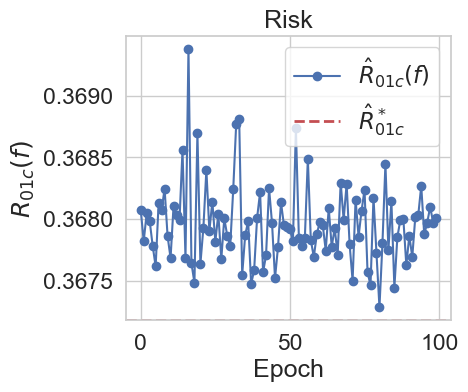

In [134]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
sns.set_context("notebook", font_scale=1.5)
test_01c = training_log_dict['track_01c']
train_loss = training_log_dict['track_epoch_loss']
optimal_l01c = training_log_dict['optimal_l01c']
    
#plt.plot(train_loss, label=r'$\hat{R}_{hinge}(f)$', marker='o')   
plt.plot(test_01c, label=r'$\hat{R}_{01c}(f)$', marker='o')
plt.axhline(y=optimal_l01c, color='r', linestyle='--', linewidth=2, label=r'$\hat{R}^*_{01c}$')
#plt.xlim([0,100])
#plt.ylim([0.37,0.4])
plt.xlabel('Epoch')
plt.ylabel(r'$R_{01c}(f)$')
plt.legend()
plt.tight_layout()
#plt.show()
plt.title('Risk')
plt.savefig(os.path.join(figure_path, prefix+'R01c.pdf'))
plt.show()





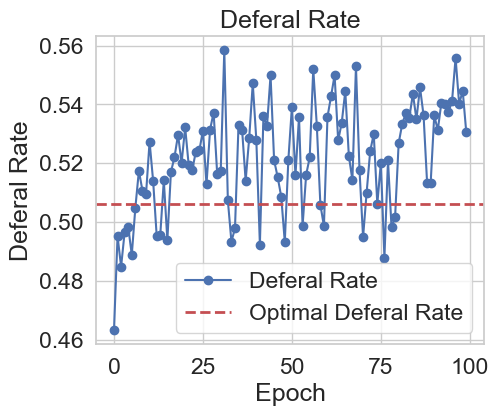

In [135]:
plt.figure(figsize=(5, 4))
plt.title('Deferal Rate')
plt.xlabel('Epoch')
plt.ylabel('Deferal Rate')
plt.plot(training_log_dict['track_avg_s'], label='Deferal Rate', marker='o')
plt.axhline(y=training_log_dict['xzy_gt_s'].mean(), color='r', linestyle='--', linewidth=2, label='Optimal Deferal Rate')
plt.legend()
plt.show()

In [136]:
colorlist = ['None', 'red', 'green', 'blue', 'orange', 'purple', 'pink', 'brown', 'gray', 'cyan', 'magenta']
n_classes = 3
#discrete color map
cmap = matplotlib.colors.ListedColormap(colorlist[1:n_classes+1])
cmap_cont = matplotlib.colors.LinearSegmentedColormap.from_list(
        "Custom", ['blue', 'green'], N=20)

def plot_xzy(x,z,y, prefix,title):
    
    num_points_max = 5000
    plt.figure(figsize=(8, 6))
    plt.title(title)
    sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max]+1, cmap=cmap, s=5, alpha=0.5)
    plt.colorbar(ticks=range(n_classes+1), label='Classes')
    plt.clim(0.5, n_classes + 0.5)
    plt.xlabel("X")
    plt.ylabel("Z")
    if not os.path.exists(figure_path):
        os.makedirs(figure_path)
    plt.savefig(os.path.join(figure_path,prefix+'xyz.pdf'))
    plt.show()
    
def plot_xzs(x,z,y, prefix,title,file_suffix=''):
    cmap = matplotlib.colors.ListedColormap(colorlist[1:3])
    
    num_points_max = 5000
    plt.figure(figsize=(8, 6))
    plt.title(title)
    sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max], cmap=cmap_cont, s=5, alpha=0.5)
    #plt.colorbar(ticks=range(3), label='Classes')
    plt.clim(0, 1)
    #override colorbar ticks to labels "Defer", "Don't Defer"
    cbar = plt.colorbar(sc)
    #cbar = plt.colorbar(sc, ticks=[0, 2])
    #cbar.ax.set_yticklabels(['Use f1', "Defer to f2"])
    plt.xlabel("X")
    plt.ylabel("Z")
    if not os.path.exists(figure_path):
        os.makedirs(figure_path)
    plt.savefig(os.path.join(figure_path,prefix+file_suffix+'.pdf'))
    plt.show()


    


In [137]:
training_log_dict['f1 acc']

tensor(0.6111)

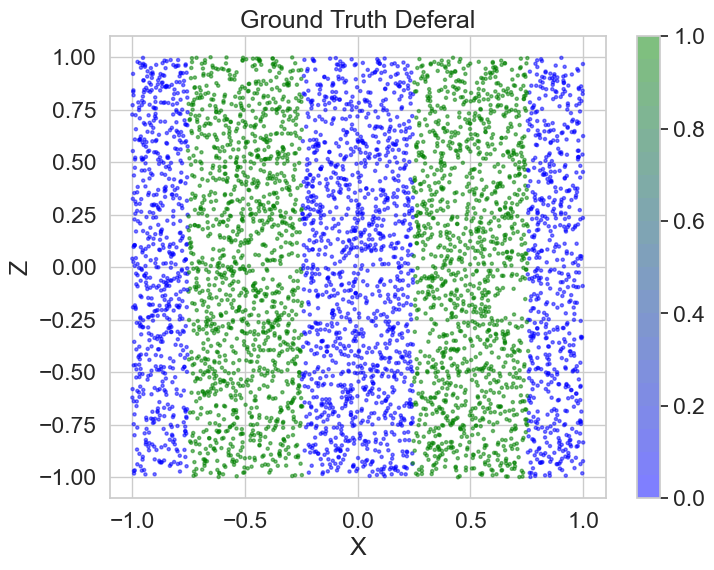

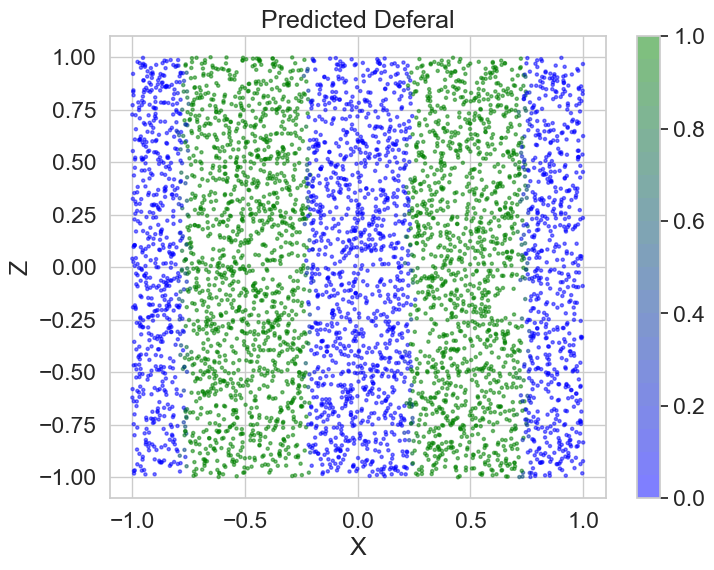

In [138]:
#torch.max(training_log_dict['xzy_t2'],dim=-1).indices
title = 'Ground Truth Deferal'
plot_xzs(training_log_dict['xzy_x'], training_log_dict['xzy_z'],training_log_dict['xzy_gt_s'], prefix, title,file_suffix='_gt_s')
title = 'Predicted Deferal'
plot_xzs(training_log_dict['xzy_x'], training_log_dict['xzy_z'],training_log_dict['xzy_s'], prefix, title,file_suffix='_s')

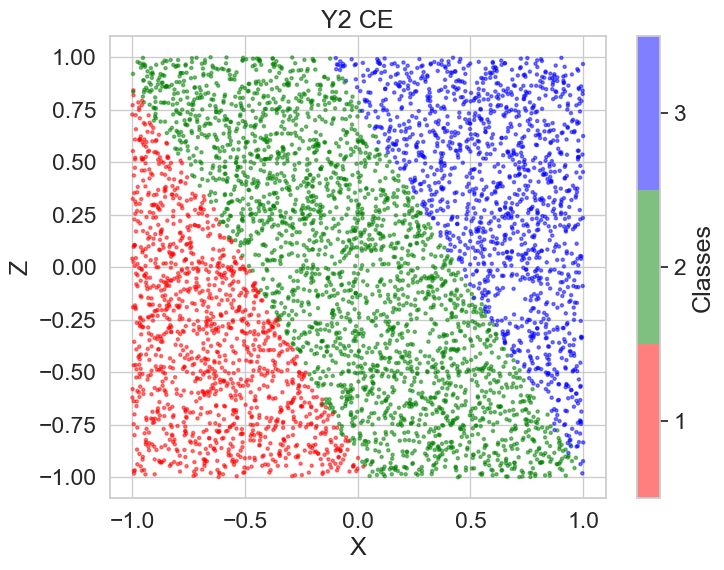

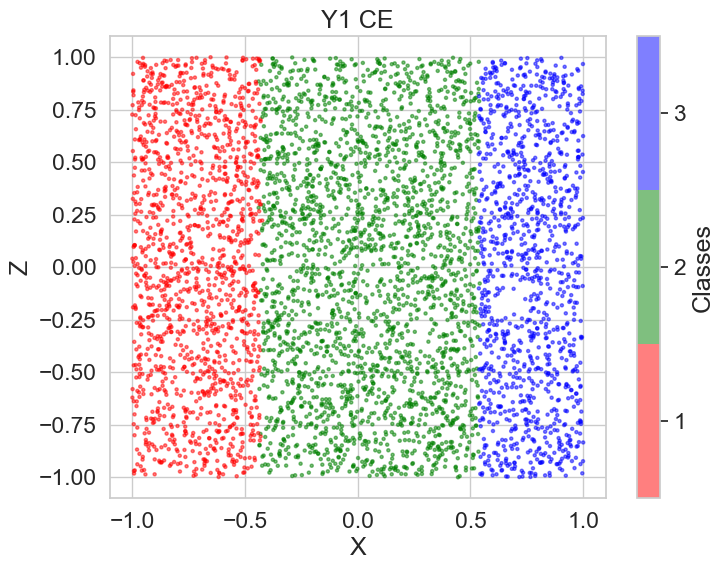

In [139]:
title = 'Y2 CE'
plot_xzy(training_log_dict['xzy_x'], training_log_dict['xzy_z'],torch.max(training_log_dict['xzy_t2'],dim=-1).indices, prefix, title)
title = 'Y1 CE'
plot_xzy(training_log_dict['xzy_x'], training_log_dict['xzy_z'],torch.max(training_log_dict['xzy_t1'],dim=-1).indices, prefix, title)


(array([142707.,   2837.,   1835.,   1554.,   1290.,   1447.,   1569.,
          1828.,   2733., 162200.]),
 array([1.46877345e-12, 9.99998674e-02, 1.99999735e-01, 2.99999595e-01,
        3.99999470e-01, 4.99999344e-01, 5.99999189e-01, 6.99999094e-01,
        7.99998939e-01, 8.99998784e-01, 9.99998689e-01]),
 <BarContainer object of 10 artists>)

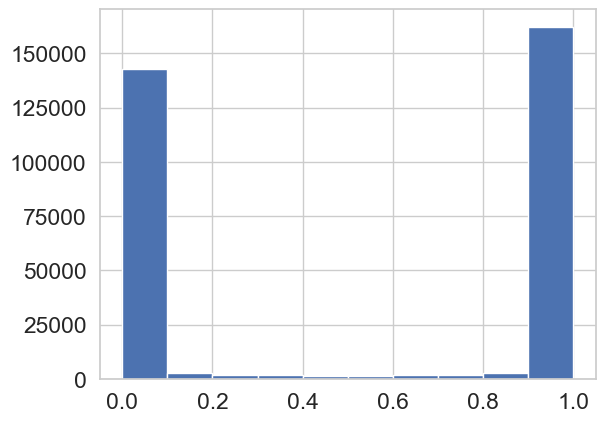

In [140]:
plt.hist(training_log_dict['xzy_s'])

In [141]:
#select s where x < 0
xzy_x = training_log_dict['xzy_x']
xzy_s = training_log_dict['xzy_s']
xyz_gt_s = training_log_dict['xzy_gt_s']

xyz_s_neg = xzy_s[xzy_x[:,0] < 0]
xyz_s_pos = xzy_s[xzy_x[:,0] >= 0]

xyz_gt_s_neg = xyz_gt_s[xzy_x[:,0] < 0]
xyz_gt_s_pos = xyz_gt_s[xzy_x[:,0] >= 0]

In [142]:
print(xyz_s_neg.mean())
print(xyz_s_pos.mean())

tensor(0.5515)
tensor(0.5095)


In [143]:
print(xyz_gt_s_neg.mean())
print(xyz_gt_s_pos.mean())

tensor(0.5057)
tensor(0.5069)


# Plot: 2 rows, 4 columns


In [144]:
baseline = 'new2_multi_2s_exp'
cost = ['0.03','0.07']
n_classes = [3,5]
prefixes = [baseline+str(c)+'_k' +str(n) for n in n_classes for c in cost]
#prefixes_CE = ['CE_'+baseline+str(c)+'_k' +str(n) for n in n_classes for c in cost]
training_log_dicts = [load_experiment_of_cost_and_class(baseline, c, n) for n in n_classes for c in cost]
#training_log_dicts_CE = [load_experiment_of_cost_and_class('CE_multi_2s_exp', c, n) for n in n_classes for c in cost]

/Users/florencer/git/EE_synthetic/Final results/new2_multi_2s_exp0.03_k3__training_result.pkl
/Users/florencer/git/EE_synthetic/Final results/new2_multi_2s_exp0.07_k3__training_result.pkl
/Users/florencer/git/EE_synthetic/Final results/new2_multi_2s_exp0.03_k5__training_result.pkl
/Users/florencer/git/EE_synthetic/Final results/new2_multi_2s_exp0.07_k5__training_result.pkl


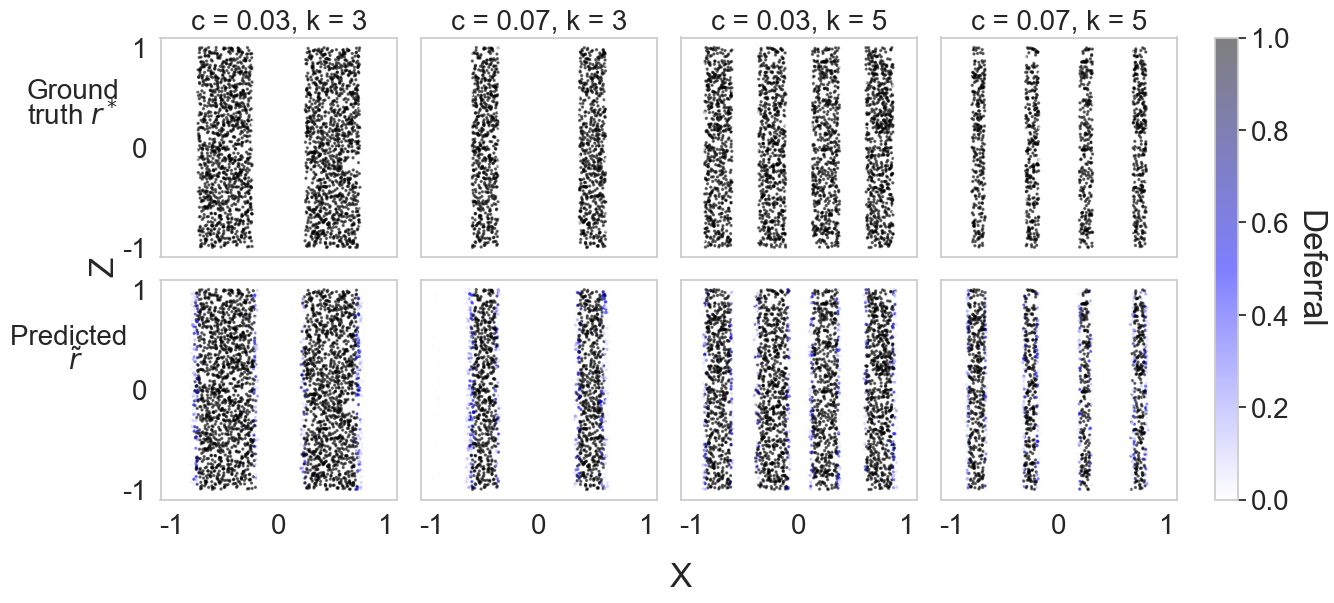

In [145]:
#figure: 3 rows, 4 columns
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
#fontsize
from matplotlib.colors import LinearSegmentedColormap
cmap_cont = matplotlib.colors.LinearSegmentedColormap.from_list(
        "Custom", ['blue', 'green'], N=20)
white_red_black = LinearSegmentedColormap.from_list(
    "white_red_black", ["#ffffff", "#0000ff", "#000000"]
)
cmap_cont = white_red_black
#cmap_cont = 'viridis'
plt.subplots_adjust(hspace=0.1, wspace=0.1)
for i, (prefix, training_log_dict) in enumerate(zip(prefixes, training_log_dicts)):
    x = training_log_dict['xzy_x']
    z = training_log_dict['xzy_z']
    y = training_log_dict['xzy_gt_s']
    num_points_max = 5000
    plt.subplot(2, 4, i+1)
    plt.title(f'c = {cost[i%2]}, k = {n_classes[i//2]}', fontsize=20)
    sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max], cmap=cmap_cont, s=2, alpha=0.5)
    #plt.colorbar(ticks=range(3), label='Classes')
    plt.clim(0, 1)
    plt.yticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    #plt.xticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    plt.xticks([], [])
    #override colorbar ticks to labels "Defer", "Don't Defer"
    if i > 0:
        #remove y axis label
        plt.yticks([], [])
    #remove gridlines
    plt.grid(False)
    #cbar = plt.colorbar(sc, ticks=[0, 2])
    #cbar.ax.set_yticklabels(['Use f1', "Defer to f2"])
    
    
for i, (prefix, training_log_dict) in enumerate(zip(prefixes, training_log_dicts)):
    x = training_log_dict['xzy_x']
    z = training_log_dict['xzy_z']
    y = training_log_dict['xzy_s']
    num_points_max = 5000
    plt.subplot(2, 4, 4+i+1)
    #plt.title(f'c = {cost[i%2]}, k = {n_classes[i//2]}', fontsize=20)
    sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max], cmap=cmap_cont, s=2, alpha=0.5)
    #plt.colorbar(ticks=range(3), label='Classes')
    plt.clim(0, 1)
    plt.yticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    #plt.xticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    plt.xticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
    #override colorbar ticks to labels "Defer", "Don't Defer"
    if i > 0:
        #remove y axis label
        plt.yticks([], [])
    #remove gridlines
    plt.grid(False)
    #cbar = plt.colorbar(sc, ticks=[0, 2])
    #cbar.ax.set_yticklabels(['Use f1', "Defer to f2"])

# for i, (prefix_CE, training_log_dict_CE) in enumerate(zip(prefixes_CE, training_log_dicts_CE)):
#     x = training_log_dict_CE['xzy_x']
#     z = training_log_dict_CE['xzy_z']
#     y = training_log_dict_CE['xzy_s']
#     num_points_max = 5000
#     plt.subplot(3, 4, 8+i+1)
#     #plt.title(f'c = {cost[i%2]}, k = {n_classes[i//2]}', fontsize=20)
#     sc = plt.scatter(x[:num_points_max,:], z[:num_points_max,:], c=y[:num_points_max], cmap=cmap_cont, s=0.5, alpha=0.5)
#     #plt.colorbar(ticks=range(3), label='Classes')
#     plt.clim(0, 1)
#     plt.yticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
#     plt.xticks([-1, 0, 1], ['-1', '0', '1'], fontsize=20)
#     #override colorbar ticks to labels "Defer", "Don't Defer"
#     if i > 0:
#         #remove y axis label
#         plt.yticks([], [])
#     #remove gridlines
#     plt.grid(False)
    #cbar = plt.colorbar(sc, ticks=[0, 2])
    #cbar.ax.set_yticklabels(['Use f1', "Defer to f2"])

#one colorbar for all subplots
cbar = plt.colorbar(sc, ax=plt.gcf().axes, orientation='vertical', pad=0.03)
#change fontsize of colorbar ticks
cbar.ax.tick_params(labelsize=20)
cbar.set_label(r"Deferral", rotation=270, labelpad=25, fontsize=24)
#X axis label on full plot
fig.text(0.45, -0.02, 'X', ha='center', va='center', fontsize=24)
fig.text(0.09, 0.5, 'Z', ha='center', va='center', rotation='vertical', fontsize=24)
fig.text(0.07, 0.79, 'Ground', ha='center', va='center', fontsize=20)
fig.text(0.07, 0.75, r'truth $r^*$', ha='center', va='center', fontsize=20)
fig.text(0.07, 0.38, r'Predicted ', ha='center', va='center', fontsize=20)
fig.text(0.07, 0.34, r' $\tilde{r}$', ha='center', va='center', fontsize=20)
#fig.text(0.02, 0.46, 'Predicted', ha='center', va='center', fontsize=24)
#fig.text(0.02, 0.27, 'CE Loss', ha='center', va='center', fontsize=24)
#fig.text(0.02, 0.20, 'Predicted', ha='center', va='center', fontsize=24)


plt.savefig(os.path.join(figure_path, 'all_deferal.pdf'),bbox_inches = 'tight', pad_inches = 0)    
plt.show()